# 03 — Ensemble Models: Bagging vs Boosting

The Logistic Regression baseline from notebook 02 set the floor: F1 ≈ 0.14, ROC AUC ≈ 0.97. High recall (87%) but very low precision (8%) — the model flags too many healthy drives as failures. In a production data center, that means unnecessary replacements and wasted labor.

The challenge is improving precision without sacrificing recall. A missed failure (false negative) is far more costly than a false alarm (false positive) — a $30 drive replacement vs a cascading array failure that takes down services. The model must favor recall, but not at the cost of being unusable.

This notebook explores two ensemble strategies:

- **Bagging** (Random Forest): trains trees in parallel on bootstrap samples, reduces variance
- **Boosting** (AdaBoost): trains trees sequentially, each correcting the previous mistakes, reduces bias

Both handle the 0.335% failure rate differently — class weights vs synthetic oversampling (SMOTE).

1. **Load** feature set and split from notebook 02
2. **Random Forest** with `class_weight="balanced"` (bagging)
3. **SMOTE** — RF with synthetic oversampling
4. **AdaBoost** (boosting baseline)
5. **Curves and comparison** — ROC, PR, metrics table
6. **Feature importance** — RF Gini vs mutual information

In [1]:
import json, os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sys.path.insert(0, os.path.join(os.pardir, "src"))
from features import CRITICAL_SMART

GREEN = "#1a7f37"
RED = "#cf222e"
GRAY = "#57606a"

## 1. Load data and split from notebook 02

In [2]:
df = pd.read_parquet(os.path.join(os.pardir, "data", "processed", "drives.parquet"))

# Reproduce encoding from notebook 02
df = df.drop(columns=["serial_number", "model"])
df = pd.get_dummies(df, columns=["manufacturer"], drop_first=True, dtype=int)

with open(os.path.join(os.pardir, "data", "processed", "feature_selection.json")) as f:
    artifacts = json.load(f)

feature_cols = artifacts["feature_cols"]
train_idx = artifacts["train_idx"]
test_idx = artifacts["test_idx"]

X_train = df.loc[train_idx, feature_cols]
X_test = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, "failure"]
y_test = df.loc[test_idx, "failure"]

# Load baseline for comparison
lr = joblib.load(os.path.join(os.pardir, "models", "baseline_lr.joblib"))
scaler = joblib.load(os.path.join(os.pardir, "models", "scaler.joblib"))

print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} ({y_train.mean()*100:.3f}% failure)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean()*100:.3f}% failure)")

Features: 40
Train: 254,740 (0.335% failure)
Test:  63,686 (0.334% failure)


/Users/aroaxinping/drive-failure-predictor/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/aroaxinping/drive-failure-predictor/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Random Forest — class_weight="balanced"

Random Forest is a **bagging** ensemble: it trains many decision trees, each on a bootstrap sample (random subset with replacement) of the data, and averages their predictions. On top of that, each tree only considers a random subset of features at every split (**random subspace method**). This double randomness reduces variance and makes the model robust to noise.

It doesn't need feature scaling — trees split on thresholds, so the absolute magnitude of values doesn't matter. We use `class_weight="balanced"` to weight the minority class proportionally.

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest (class_weight='balanced', n_estimators=300)")
print("=" * 55)
print(f"F1 score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Avg Prec:  {average_precision_score(y_test, y_proba_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["healthy", "failure"]))

Random Forest (class_weight='balanced', n_estimators=300)
F1 score:  0.9549
ROC AUC:   0.9976
Avg Prec:  0.9740

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     63473
     failure       0.97      0.94      0.95       213

    accuracy                           1.00     63686
   macro avg       0.98      0.97      0.98     63686
weighted avg       1.00      1.00      1.00     63686



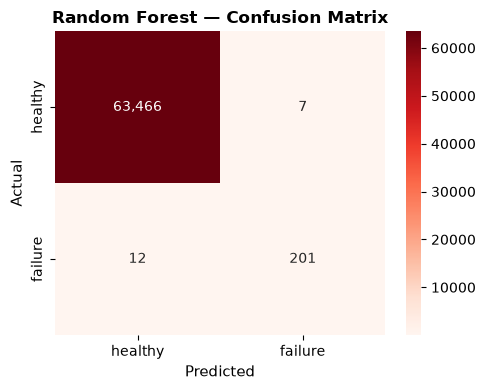

True Positives:  201 (failures caught)
False Negatives: 12 (failures missed)
False Positives: 7 (false alarms)


In [4]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_rf, annot=True, fmt=",d", cmap="Reds",
    xticklabels=["healthy", "failure"],
    yticklabels=["healthy", "failure"],
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title("Random Forest — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Positives:  {tp} (failures caught)")
print(f"False Negatives: {fn} (failures missed)")
print(f"False Positives: {fp} (false alarms)")

## 3. Random Forest + SMOTE

SMOTE generates synthetic examples of the minority class (failures) by interpolating between existing failure cases. This balances the training set before fitting the model, instead of relying on class weights.

We compare RF with `class_weight="balanced"` (above) vs RF with SMOTE to see which handles the imbalance better.

In [5]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print(f"\nRandom Forest + SMOTE")
print("=" * 55)
print(f"F1 score:  {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_smote):.4f}")
print(f"Avg Prec:  {average_precision_score(y_test, y_proba_smote):.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=["healthy", "failure"]))

Before SMOTE: {0: 253886, 1: 854}
After SMOTE:  {0: 253886, 1: 253886}



Random Forest + SMOTE
F1 score:  0.9506
ROC AUC:   0.9975
Avg Prec:  0.9740

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     63473
     failure       0.95      0.95      0.95       213

    accuracy                           1.00     63686
   macro avg       0.98      0.97      0.98     63686
weighted avg       1.00      1.00      1.00     63686



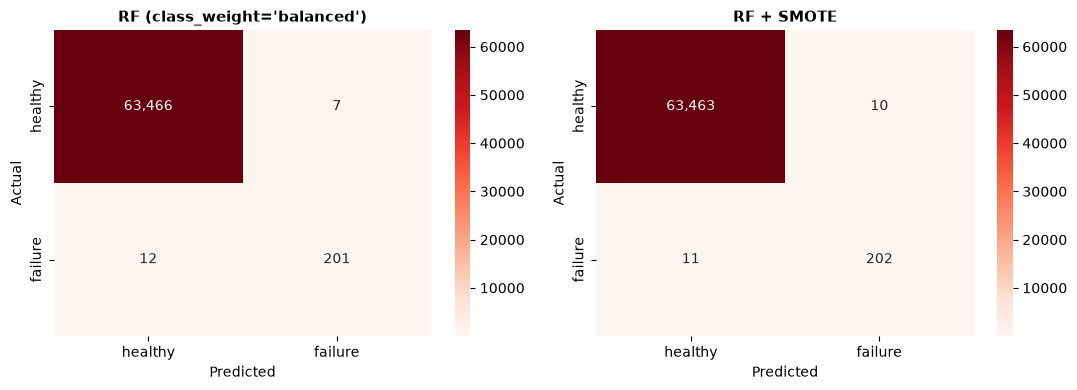

In [6]:
# Confusion matrix — RF + SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm, title in [
    (axes[0], cm_rf, "RF (class_weight='balanced')"),
    (axes[1], cm_smote, "RF + SMOTE"),
]:
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Reds",
        xticklabels=["healthy", "failure"],
        yticklabels=["healthy", "failure"],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 3.1 AdaBoost — boosting baseline

While Random Forest uses **bagging** (parallel, reduces variance), **boosting** trains models sequentially — each new model focuses on the mistakes of the previous one. AdaBoost is the simplest boosting method: it reweights misclassified samples so the next tree pays more attention to them.

This is a quick comparison between the two ensemble families before we move to XGBoost (gradient boosting) in notebook 04.

In [7]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

print("AdaBoost (200 stumps, lr=0.1)")
print("=" * 55)
print(f"F1 score:  {f1_score(y_test, y_pred_ada):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_ada):.4f}")
print(f"Avg Prec:  {average_precision_score(y_test, y_proba_ada):.4f}")
print()
print(classification_report(y_test, y_pred_ada, target_names=["healthy", "failure"]))

AdaBoost (200 stumps, lr=0.1)
F1 score:  0.9140
ROC AUC:   0.9968
Avg Prec:  0.9527

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00     63473
     failure       0.96      0.87      0.91       213

    accuracy                           1.00     63686
   macro avg       0.98      0.94      0.96     63686
weighted avg       1.00      1.00      1.00     63686



## 4. ROC & Precision-Recall — all models

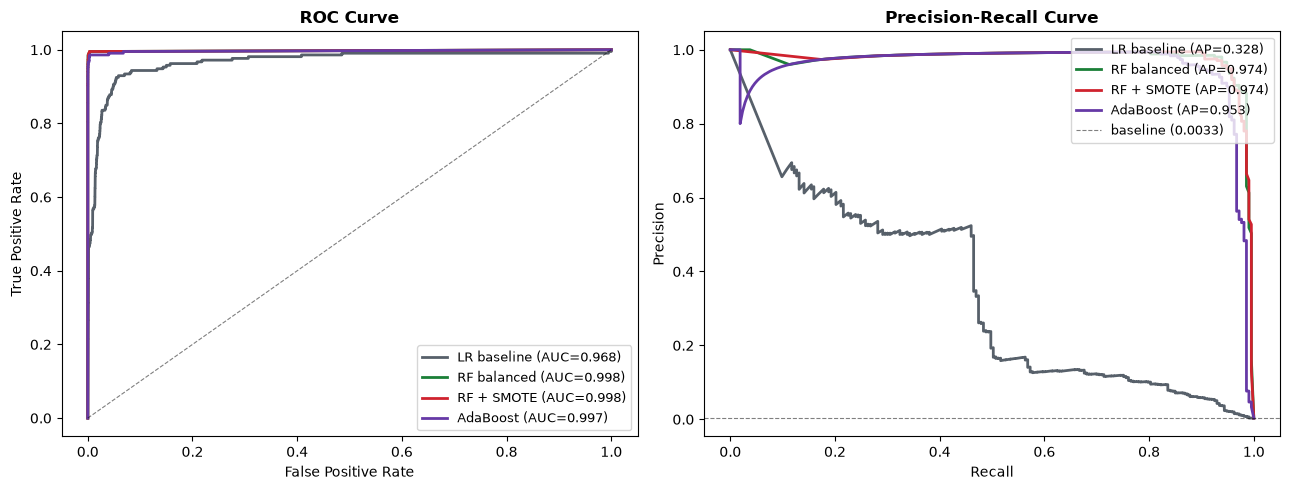

In [8]:
# Baseline LR predictions for comparison
X_test_scaled = scaler.transform(X_test)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

models = {
    "LR baseline": (y_proba_lr, GRAY),
    "RF balanced": (y_proba_rf, GREEN),
    "RF + SMOTE": (y_proba_smote, RED),
    "AdaBoost": (y_proba_ada, "#6639a6"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
for name, (proba, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9)

# Precision-Recall
for name, (proba, color) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y=y_test.mean(), color="k", lw=0.8, ls="--", alpha=0.5, label=f"baseline ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Cross-validation

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RF balanced
rf_cv = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=2
)
cv_f1_rf = cross_val_score(rf_cv, X_train, y_train, cv=skf, scoring="f1")
cv_roc_rf = cross_val_score(rf_cv, X_train, y_train, cv=skf, scoring="roc_auc")

# RF + SMOTE (using imblearn Pipeline for proper CV)
smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2)),
])
cv_f1_smote = cross_val_score(smote_pipe, X_train, y_train, cv=skf, scoring="f1")
cv_roc_smote = cross_val_score(smote_pipe, X_train, y_train, cv=skf, scoring="roc_auc")

print("5-Fold Stratified CV")
print("=" * 60)
print(f"RF balanced  — F1: {cv_f1_rf.mean():.4f} ± {cv_f1_rf.std():.4f}  |  AUC: {cv_roc_rf.mean():.4f} ± {cv_roc_rf.std():.4f}")
print(f"RF + SMOTE   — F1: {cv_f1_smote.mean():.4f} ± {cv_f1_smote.std():.4f}  |  AUC: {cv_roc_smote.mean():.4f} ± {cv_roc_smote.std():.4f}")

5-Fold Stratified CV
RF balanced  — F1: 0.9528 ± 0.0153  |  AUC: 0.9976 ± 0.0022
RF + SMOTE   — F1: 0.9548 ± 0.0138  |  AUC: 0.9981 ± 0.0015


## 6. Feature importance

Random Forest provides feature importance based on how much each feature reduces impurity (Gini) across all trees. We compare this ranking with the mutual information scores from notebook 02.

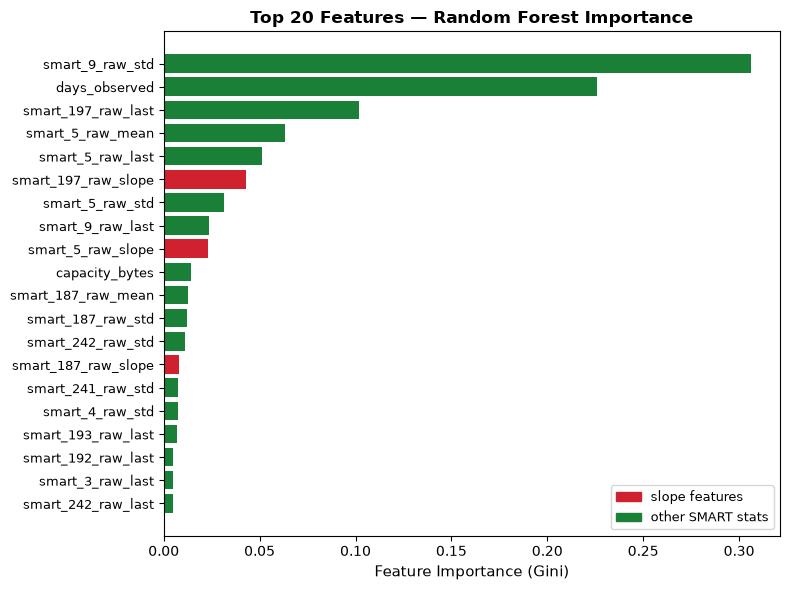

In [10]:
# Best RF model feature importance
best_rf = rf  # or rf_smote — pick whichever scored better on F1
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_imp = importances.head(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if "slope" in f else GREEN for f in top_imp.index]
ax.barh(range(len(top_imp)), top_imp.values, color=colors)
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp.index, fontsize=9)
ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title("Top 20 Features — Random Forest Importance", fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color=RED, label="slope features"), Patch(color=GREEN, label="other SMART stats")],
    loc="lower right", fontsize=9
)
plt.tight_layout()
plt.show()

In [11]:
# Compare MI ranking (notebook 02) vs RF feature importance
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=5)
mi = pd.Series(mi_scores, index=feature_cols)

comparison = pd.DataFrame({
    "MI_rank": mi.rank(ascending=False).astype(int),
    "RF_rank": importances.rank(ascending=False).astype(int),
    "MI_score": mi,
    "RF_importance": importances,
}).sort_values("RF_rank")

print("Top 15 by RF importance vs MI ranking:")
print(comparison.head(15).to_string())

rank_corr = comparison["MI_rank"].corr(comparison["RF_rank"], method="spearman")
print(f"\nSpearman rank correlation (MI vs RF): {rank_corr:.3f}")

Top 15 by RF importance vs MI ranking:
                     MI_rank  RF_rank  MI_score  RF_importance
smart_9_raw_std            2        1  0.014830       0.306030
days_observed              1        2  0.034574       0.226000
smart_197_raw_last         3        3  0.007800       0.101828
smart_5_raw_mean           9        4  0.005756       0.063076
smart_5_raw_last           8        5  0.005874       0.051251
smart_197_raw_slope        4        6  0.007337       0.042705
smart_5_raw_std            6        7  0.006025       0.031267
smart_9_raw_last          16        8  0.003503       0.023382
smart_5_raw_slope          5        9  0.006030       0.023202
capacity_bytes             7       10  0.005916       0.014332
smart_187_raw_mean        13       11  0.003844       0.012485
smart_187_raw_std         10       12  0.004680       0.012263
smart_242_raw_std         15       13  0.003810       0.010947
smart_187_raw_slope       11       14  0.004647       0.007718
smart_241_raw_st

## 7. Model comparison table

In [12]:
y_pred_lr = lr.predict(X_test_scaled)

def get_metrics(y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "F1": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba),
        "Avg Precision": average_precision_score(y_true, y_proba),
        "Recall": report["1"]["recall"],
        "Precision": report["1"]["precision"],
    }

results = pd.DataFrame([
    {"Model": "Logistic Regression", **get_metrics(y_test, y_pred_lr, y_proba_lr)},
    {"Model": "RF (balanced)", **get_metrics(y_test, y_pred_rf, y_proba_rf)},
    {"Model": "RF + SMOTE", **get_metrics(y_test, y_pred_smote, y_proba_smote)},
    {"Model": "AdaBoost", **get_metrics(y_test, y_pred_ada, y_proba_ada)},
]).set_index("Model")

results.style.format("{:.4f}").highlight_max(axis=0, color="#d4edda")

,F1,ROC AUC,Avg Precision,Recall,Precision
Model,,,,,
Logistic Regression,0.1347,0.9678,0.3278,0.8498,0.0732
RF (balanced),0.9549,0.9976,0.9740,0.9437,0.9663
RF + SMOTE,0.9506,0.9975,0.9740,0.9484,0.9528
AdaBoost,0.9140,0.9968,0.9527,0.8732,0.9588


## 8. Save best model

In [13]:
from pathlib import Path

models_dir = Path(os.pardir) / "models"

# Save best RF variant
f1_balanced = f1_score(y_test, y_pred_rf)
f1_smote = f1_score(y_test, y_pred_smote)

if f1_smote > f1_balanced:
    joblib.dump(rf_smote, models_dir / "rf_best.joblib")
    print(f"Saved RF + SMOTE (F1={f1_smote:.4f}) as rf_best.joblib")
else:
    joblib.dump(rf, models_dir / "rf_best.joblib")
    print(f"Saved RF balanced (F1={f1_balanced:.4f}) as rf_best.joblib")

Saved RF balanced (F1=0.9549) as rf_best.joblib


## Summary

| Model | Type | F1 | ROC AUC | Recall | Precision |
|---|---|---|---|---|---|
| Logistic Regression | linear | ~0.14 | ~0.97 | ~87% | ~8% |
| RF (balanced) | bagging | ? | ? | ? | ? |
| RF + SMOTE | bagging + oversampling | ? | ? | ? | ? |
| AdaBoost | boosting | ? | ? | ? | ? |

*(Table filled after execution)*

**Bagging vs Boosting**: Random Forest (bagging) reduces variance through parallel trees on random subsets. AdaBoost (boosting) reduces bias by focusing each tree on prior mistakes. Both are ensemble methods but attack different sources of error.

The best model from this notebook is saved to `models/`. Next notebook: **XGBoost** (gradient boosting) with hyperparameter tuning via Grid Search.